> **Note:** This environment variable is required for fully deterministic CuBLAS ops on CUDA >= 10.2 when `reproducible=True` is set below. Without it, PyTorch raises a `RuntimeError` instead of training deterministically. It must be set before `torch` is imported. See the [README FAQ](../../README.md#reproducibility-and-cublas_workspace_config) for details.

In [ ]:
%env CUBLAS_WORKSPACE_CONFIG=:16:8

# How To Use Stackix

Stackix is our implementation of a stacked/hierarchical autoencoder.  
This tutorial follows the structure of our `Getting Started - Vanillix`, but is less extensive because  
our pipeline works similarly for different architectures. Here, we focus only on Stackix specifics.

**AUTOENCODIX** supports far more functionality than shown here, so we’ll also point to advanced tutorials where relevant.  

**IMPORTANT**

> This tutorial only shows the specifics of the Stackix pipeline. If you're unfamiliar with general concepts,  
> we recommend following the [`Getting Started - Vanillix`](./Vanillix.ipynb) tutorial first.

## Stackix Theory

In our implementation, we train one variational autoencoder (VAE) per data modality end-to-end.  
The latent spaces of these *outer* autoencoders are then concatenated and used as input to another *inner* autoencoder.  
Downstream visualization and evaluation are performed on this **meta-latent space**, which represents a joint embedding of all modalities.  

For unpaired data, each outer autoencoder is trained on all available samples of its modality, even if the corresponding sample is missing in other modalities.  
When constructing the input for the inner autoencoder, non-overlapping samples are dropped to ensure consistency across modalities.  

This approach has two main goals:  
1. To produce more informative latent spaces for each modality.  
2. To provide a richer, joint representation for the inner autoencoder.  

We also store the dropped samples and their indices. This allows us to reconstruct the full dataset: the output of the inner autoencoder can be passed back through the outer autoencoders, where decoding recovers the original modalities.  

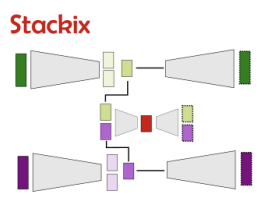

## What You'll Learn

You’ll learn how to:

1. **Initialize** the pipeline and run it. <br><br>
2. Understand the Stackix-specific **pipeline steps** (paired vs. unpaired data). <br><br>
3. Access the Stackix-specific **results** (sub-results for "outer" autoencoders). <br><br>
4. **Visualize** outputs. <br><br>
5. Apply **custom parameters**. <br><br>
6. **Save, load, and reuse** a trained pipeline. <br><br>

Let’s get started! 🚀


## 1) Initialize and Run Stackix

We set a few custom parameters of the config file. For a deep dive into the config object, see:

[`Tutorials/DeepDives/ConfigTutorial.ipynb`](../DeepDives/ConfigTutorial.ipynb)

#### 1.1 The Dataset

We use a real multi-omics dataset: a balanced subset of the TCGA pan-cancer cohort ([`autoencodix/tcga`](https://huggingface.co/datasets/autoencodix/tcga) on Hugging Face), combining RNA-seq and DNA methylation.
The dataset is accompanied by clinical annotation data containing metadata such as cancer type.


In [ ]:
import pandas as pd
from huggingface_hub import hf_hub_download

import autoencodix as acx
from autoencodix.configs.default_config import DataCase
from autoencodix.configs.stackix_config import StackixConfig
from autoencodix.data.datapackage import DataPackage

# Data is hosted on Hugging Face Hub (autoencodix/tcga) and downloaded (and locally cached) automatically
HF_REPO_ID = "autoencodix/tcga"
rna_path = hf_hub_download(repo_id=HF_REPO_ID, repo_type="dataset", filename="rna.parquet")
meth_path = hf_hub_download(repo_id=HF_REPO_ID, repo_type="dataset", filename="methylation.parquet")
clin_path = hf_hub_download(repo_id=HF_REPO_ID, repo_type="dataset", filename="clinical.parquet")

rna_full = pd.read_parquet(rna_path)
meth_full = pd.read_parquet(meth_path)
clin_full = pd.read_parquet(clin_path)

# Keep only samples present in all three modalities
shared_ids = rna_full.index.intersection(meth_full.index).intersection(clin_full.index)

# Balanced subsample across the 5 broad TCGA cancer types
n_per_type = 120
sampled_ids = (
    clin_full.loc[shared_ids]
    .groupby("CANCER_TYPE", group_keys=False)
    .apply(lambda g: g.sample(n=min(n_per_type, len(g)), random_state=42), include_groups=False)
    .index
)

raw_rna = rna_full.loc[sampled_ids]
raw_meth = meth_full.loc[sampled_ids]
annotation = clin_full.loc[sampled_ids]

tcga_multi_bulk = DataPackage(
    multi_bulk={"rna": raw_rna, "meth": raw_meth},
    annotation={"paired": annotation},
)

my_config = StackixConfig(
    epochs=100,
    beta=0.01,
    checkpoint_interval=5,
    default_vae_loss="kl",  # kl or mmd possible
    data_case=DataCase.MULTI_BULK,
    k_filter=2000,
    reproducible=True,
    global_seed=5,
)

print("\n")
print("Starting Pipeline")
print("-" * 50)
print("-" * 50)
stackix = acx.Stackix(data=tcga_multi_bulk, config=my_config)
result = stackix.run()



Starting Pipeline
--------------------------------------------------
--------------------------------------------------
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
anno key: paired
Reproducibility settings for device auto are not implemented or necessary i.e. for cpu.
Training each modality model...
Training modality: rna
Training modality: rna
Reproducibility settings for device auto are not implemented or necessary i.e. for cpu.
Epoch 1 - Train Loss: 1140.4230
Sub-losses: recon_loss: 1140.4230, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 1 - Valid Loss: 890.9659
Sub-losses: recon_loss: 890.9659, var_loss: 0.0000, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Train Loss: 1072.0155
Sub-losses: recon_loss: 1072.0155, var_loss: 0.0000, anneal_factor: 0.0001, effective_beta_factor: 0.0000
Epoch 2 - Valid Loss: 1232.9457
Sub-losses: recon_loss: 1232.9455, var_loss: 0.0001, anneal_factor: 0.0001

## 2) Stackix-Specific Steps

Stackix does not introduce additional steps to the overall pipeline. However, its preprocessing and training differ slightly from Varix and Vanillix.
Stackix processes each data modality individually and thus supports unpaired data input.

This is enabled by setting the config parameter `requires_paired=False`.
In the following example, we build unpaired data by dropping some samples from our raw_rna data. The outer autoencoder for the methylation modality still trains on all methylation samples, including those without corresponding RNA. These RNA samples are only excluded when concatenating the latent spaces for the inner autoencoder. Later, we can add these samples back to the inner AE output and feed them into the decoder of the outer methylation autoencoder, allowing full reconstruction.

In [ ]:
import pandas as pd

from autoencodix.data.datapackage import DataPackage
from autoencodix.configs.stackix_config import StackixConfig
from autoencodix.configs.default_config import DataCase
import autoencodix as acx

dropped_ids = raw_rna.sample(n=20, random_state=42).index

rna_anno: pd.DataFrame = annotation.drop(index=dropped_ids)
print(rna_anno.shape)
rna_unpaired: pd.DataFrame = raw_rna.drop(index=dropped_ids)
print(rna_unpaired.shape)
unpaired_dp: DataPackage = DataPackage(
    multi_bulk={"rna": rna_unpaired, "meth": raw_meth},
    annotation={"rna": rna_anno, "meth": annotation},
)
unpaired_config: StackixConfig = StackixConfig(
    data_case=DataCase.MULTI_BULK, requires_paired=False
)
unpaired_stackix: acx.Stackix = acx.Stackix(data=unpaired_dp, config=unpaired_config)
unpaired_result = unpaired_stackix.run()

(580, 56)
(580, 17448)
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
anno key: rna
anno key: meth
Training each modality model...
Training modality: rna
Training modality: rna
Epoch 1 - Train Loss: 21953.7533
Sub-losses: recon_loss: 21933.2038, var_loss: 20.5494, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 1 - Valid Loss: 28925.5151
Sub-losses: recon_loss: 28712.8017, var_loss: 212.7129, anneal_factor: 0.0000, effective_beta_factor: 0.0000
Epoch 2 - Train Loss: 29734.8084
Sub-losses: recon_loss: 18991.1051, var_loss: 10743.7031, anneal_factor: 0.0344, effective_beta_factor: 0.0034
Epoch 2 - Valid Loss: 20416.6821
Sub-losses: recon_loss: 20415.0345, var_loss: 1.6478, anneal_factor: 0.0344, effective_beta_factor: 0.0034
Epoch 3 - Train Loss: 17930.3715
Sub-losses: recon_loss: 17904.2104, var_loss: 26.1610, anneal_factor: 0.9656, effective_beta_factor: 0.0966
Epoch 3 - Valid Loss: 44711.3351
Sub-losses: recon_loss: 21212.3125, var_

## 3) Access Stackix-Specific Outputs

As explained above, we train *outer* autoencoders for each data modality and one shared *inner* autoencoder.  
The results (losses, reconstructions, latent spaces, etc.) for the *inner* autoencoder can be accessed in the same way as for the Vanillix autoencoder (see [1] and [2]).  
The results for the *outer* autoencoders are stored in a special `sub_results` structure, as illustrated in the Python code below.  

The `sub_results` can be accessed as an attribute of the `result` object.  
On the first level, this is a `Dict` with keys corresponding to the data modalities (as defined in Step 1).  
The value for each key is a `result` object analogous to the general result object.  
These can be accessed via our standard API (see also [2]).

[1] [`Tutorials/PipelineTutorials/Vanillix.ipynb`](./Vanillix.ipynb)  
[2] [`Tutorials/DeepDives/PipelineOutputTutorial.ipynb`](../DeepDives/PipelineOutputTutorial.ipynb)


In [3]:
outer_result = result.sub_results
print(outer_result.keys())

dict_keys(['rna', 'meth'])


In [4]:
print(outer_result["meth"])
# access latent space of outer methylation autoencoder
outer_result["meth"].latentspaces.get(split="test", epoch=-1)

Result Object Public Attributes:
------------------------------
latentspaces: TrainingDynamics object
sample_ids: TrainingDynamics object
reconstructions: TrainingDynamics object
mus: TrainingDynamics object
sigmas: TrainingDynamics object
losses: TrainingDynamics object
sub_losses: LossRegistry(_losses={'recon_loss': TrainingDynamics(), 'var_loss': TrainingDynamics(), 'anneal_factor': TrainingDynamics(), 'effective_beta_factor': TrainingDynamics()})
preprocessed_data: Tensor of shape (0,)
model: VarixArchitecture
model_checkpoints: TrainingDynamics object
datasets: DatasetContainer(train=None, valid=None, test=None)
new_datasets: DatasetContainer(train=None, valid=None, test=None)
adata_latent: AnnData object with n_obs × n_vars = 0 × 0
final_reconstruction: None
sub_results: None
sub_reconstructions: None
embedding_evaluation: Empty DataFrame
Columns: []
Index: []
embedding_attributions: Empty DataFrame
Columns: []
Index: []
embedding_explanations: Dict with 0 items


array([[-0.5793563 ,  3.3462658 ,  4.0676413 , ..., -1.1264104 ,
         8.533341  ,  0.24727045],
       [ 0.27904922,  6.3243365 ,  6.6222496 , ...,  3.8712113 ,
         8.541071  ,  0.76873565],
       [ 0.01638465,  0.2073401 , -0.5259373 , ..., -0.9908988 ,
         3.7500658 , -0.34158328],
       ...,
       [ 0.25197417,  6.083717  ,  4.4982243 , ...,  0.20654893,
        10.604482  ,  0.5866882 ],
       [ 0.25687295,  1.4875035 ,  0.1338348 , ...,  7.210355  ,
         0.820383  ,  1.4133849 ],
       [ 1.0485725 ,  3.6913567 ,  1.1244636 , ...,  0.5206223 ,
        -1.049191  , 10.351558  ]], shape=(120, 16), dtype=float32)

In [5]:
# the inner result can be accessed directly
result.latentspaces.get(split="test", epoch=-1)
# or as dataframe with ids
result.get_latent_df(split="test", epoch=-1)

,LatDim_0,LatDim_1,LatDim_2,LatDim_3,LatDim_4,LatDim_5,LatDim_6,LatDim_7,LatDim_8,LatDim_9,LatDim_10,LatDim_11,LatDim_12,LatDim_13,LatDim_14,LatDim_15
TCGA-09-0367-01,-0.716473,0.334303,5.821696,-0.764565,5.701203,4.804081,4.751423,4.066137,6.151781,4.613244,0.724952,2.013532,5.699779,-1.320663,3.004505,1.113719
TCGA-09-0369-01,0.388581,0.521705,4.956623,1.088743,2.861100,1.013601,2.587062,4.937108,2.991676,3.474394,-0.916453,-1.817731,2.075444,-0.305956,3.167891,-0.460237
TCGA-09-1670-01,0.535104,-1.035145,2.262825,0.702733,2.166391,1.590671,1.416398,2.337470,2.652190,3.611128,-0.399691,-2.304747,2.935423,-1.424145,0.799723,0.255282
TCGA-10-0928-01,0.690615,-1.203420,6.914469,0.824371,4.764842,4.057058,4.238592,4.057696,3.716496,4.051126,0.869068,0.767875,3.315935,1.144694,2.203609,1.273366
TCGA-13-0899-01,1.238776,0.681058,6.892346,-0.185644,7.450210,4.435634,6.326564,5.006801,4.997664,6.686149,1.905843,-0.102090,4.145794,-1.179466,4.355998,1.850416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-NA-A4R1-01,-0.949739,-0.336427,3.804092,0.327773,3.343694,-0.216047,1.987036,4.235099,3.298728,2.900420,0.197126,1.573203,0.776612,-0.931215,1.030211,0.779701
TCGA-NJ-A55O-01,2.819712,-1.216299,0.038453,1.382272,-0.697435,-0.007603,0.885026,0.735170,0.093063,0.735188,1.653013,0.902170,0.264285,-0.261011,0.469972,1.226536
TCGA-OY-A56Q-01,0.255358,0.904056,5.470898,0.999461,5.924256,3.096855,5.455171,3.434091,3.772222,5.106211,-0.896385,-0.678019,3.902276,-0.515420,2.475446,-0.238900
TCGA-QS-A5YQ-01,0.511213,1.147928,7.727164,-1.173102,3.462185,0.053457,0.750935,4.363729,0.660383,3.721281,6.479755,1.570146,1.100412,0.207263,11.895373,2.420819


## 4) Visualize Outputs

This works exactly as for our other pipelines, by calling the `show_result` method.  
For more information, see our [Visualization Deep Dive](../DeepDives/VisualizeTutorial.ipynb).  

We can pass a column from the annotation file using the keyword argument `params` to color the plots according to this column.

[3] [`Tutorials/DeepDives/VisualizeTutorial.ipynb`](../DeepDives/VisualizeTutorial.ipynb)


Creating plots ...


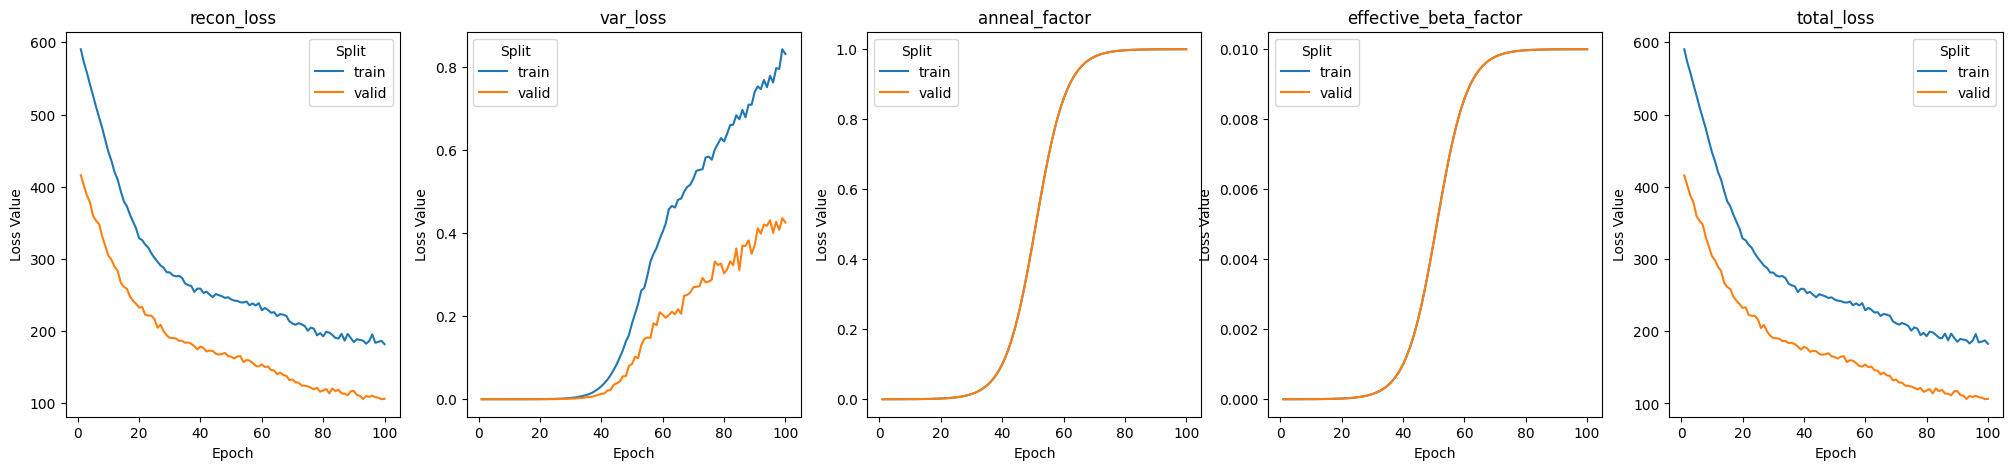

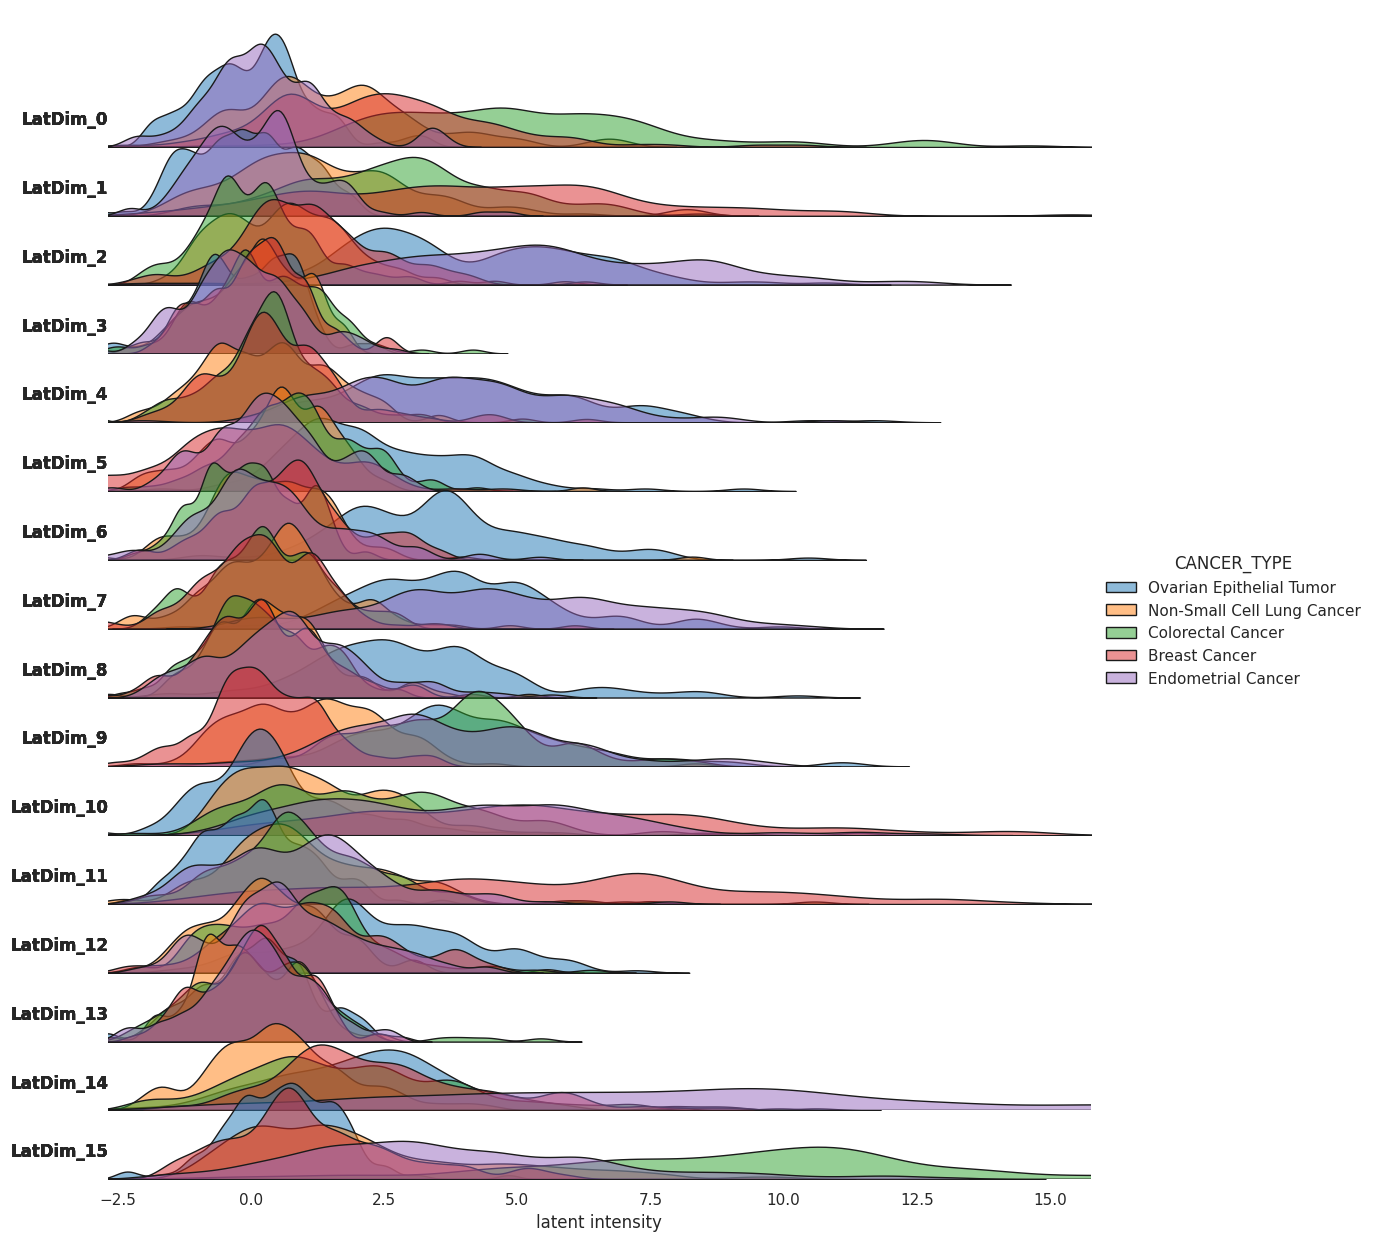

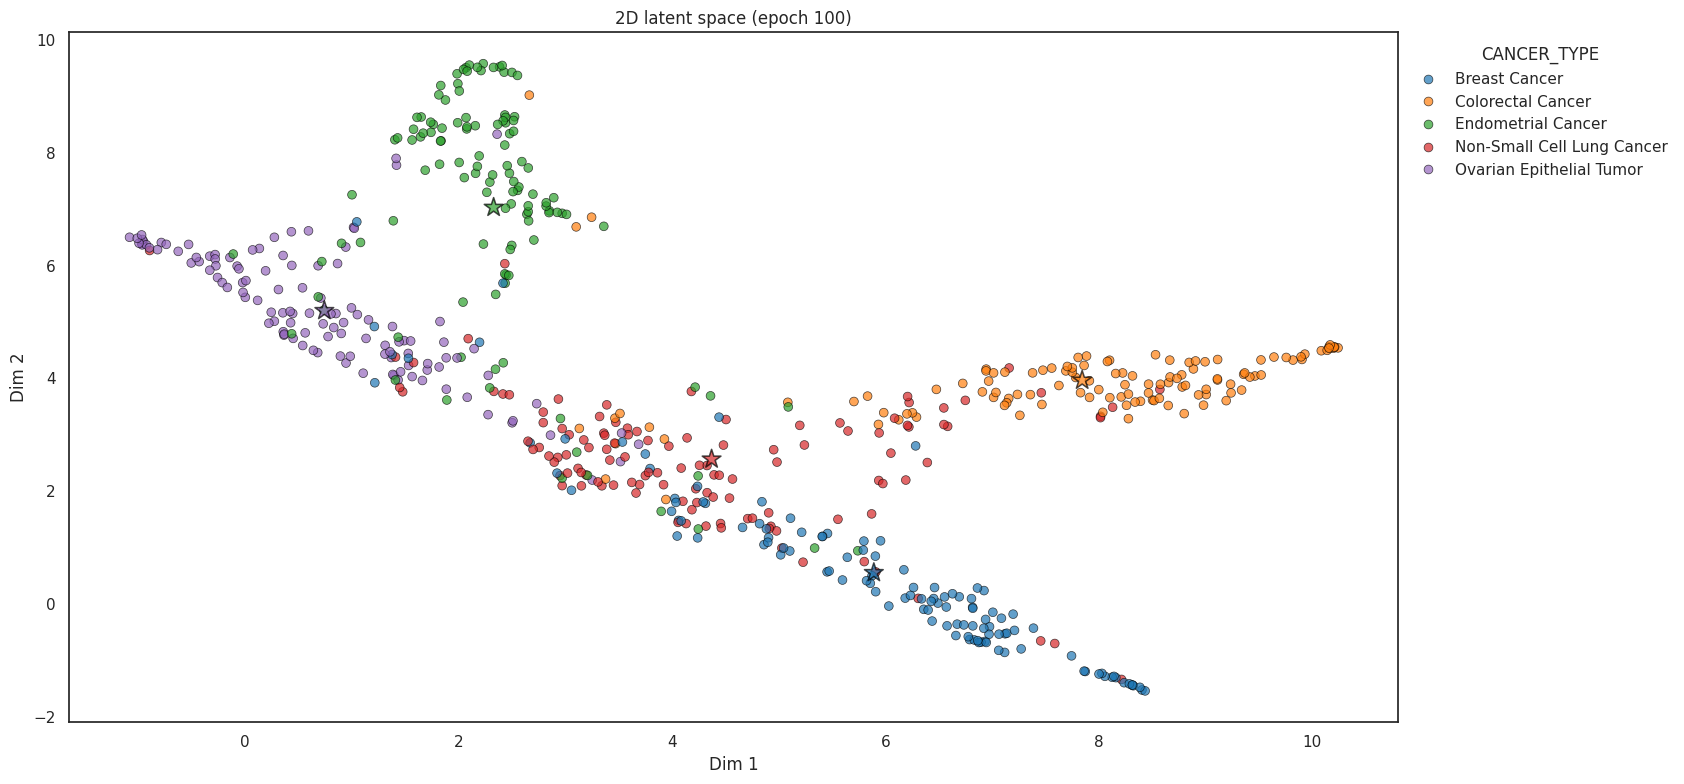

In [6]:
stackix.show_result(params=["CANCER_TYPE"])

## 5) Customize Stackix Parameters

Since Stackix is composed of variational autoencoders, there are no Stackix-specific customizations that were not already shown in the `Varix` tutorial.  

However, it is possible to change the architecture to a vanilla autoencoder via the `model_type` attribute when initializing Stackix.  
Please note that this attribute expects a **class type**, not an instance of the class.  
Therefore, you need to import the appropriate `Architecture` (see [API reference](https://maxjoas.github.io/autoencodix_package/api/modeling)) and the corresponding loss type (e.g., `VanillixLoss` if using a vanilla autoencoder).  

See the code below for a clearer example.


In [7]:
import autoencodix as acx
from autoencodix.configs.default_config import DataCase
from autoencodix.configs.stackix_config import StackixConfig
from autoencodix.modeling import VanillixArchitecture
from autoencodix.utils import VanillixLoss

my_config = StackixConfig(
    epochs=27,
    checkpoint_interval=5,
    data_case=DataCase.MULTI_BULK,
    k_filter=2000,
)
stackix_custom = acx.Stackix(
    data=tcga_multi_bulk,
    config=my_config,
    model_type=VanillixArchitecture,
    loss_type=VanillixLoss,
)
result_custom = stackix_custom.run()

in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
anno key: paired
Training each modality model...
Training modality: rna
Training modality: rna
Epoch 1 - Train Loss: 1127.6916
Sub-losses: recon_loss: 1127.6916
Epoch 1 - Valid Loss: 941.0068
Sub-losses: recon_loss: 941.0068
Epoch 2 - Train Loss: 1009.9564
Sub-losses: recon_loss: 1009.9564
Epoch 2 - Valid Loss: 862.7157
Sub-losses: recon_loss: 862.7157
Epoch 3 - Train Loss: 936.4866
Sub-losses: recon_loss: 936.4866
Epoch 3 - Valid Loss: 827.8804
Sub-losses: recon_loss: 827.8804
Epoch 4 - Train Loss: 898.6707
Sub-losses: recon_loss: 898.6707
Epoch 4 - Valid Loss: 801.9099
Sub-losses: recon_loss: 801.9099
Epoch 5 - Train Loss: 869.3544
Sub-losses: recon_loss: 869.3544
Epoch 5 - Valid Loss: 783.3687
Sub-losses: recon_loss: 783.3687
Epoch 6 - Train Loss: 846.2947
Sub-losses: recon_loss: 846.2947
Epoch 6 - Valid Loss: 767.1078
Sub-losses: recon_loss: 767.1078
Epoch 7 - Train Loss: 831.0782
Sub-losses: r

## 6) Saving, Loading and Reusing
This works for `Stackix` as for any other models, by using the `save` and `load` methods.

In [8]:
import os
import glob

outpath = os.path.join("tutorial_res", "stackix")
stackix.save(file_path=outpath, save_all=False)

folder = os.path.dirname(outpath)
pkl_files = glob.glob(os.path.join(folder, "*.pkl"))
model_files = glob.glob(os.path.join(folder, "*.pth"))

print("PKL files:", pkl_files)
print("Model files:", model_files)

# The load functionality will automatically rebuild the pipeline object
# from the saved files.
stackix_loaded = acx.Stackix.load(outpath)


Preprocessor saved successfully.
saving memory efficient
Pipeline object saved successfully.
PKL files: ['tutorial_res/van_preprocessor.pkl', 'tutorial_res/stackix_preprocessor.pkl']
Model files: ['tutorial_res/stackix_model.pth', 'tutorial_res/van_model.pth']
Attempting to load a pipeline from tutorial_res/stackix...
Pipeline object loaded successfully. Actual type: Stackix
Preprocessor loaded successfully.


In [9]:
stackix_loaded.predict(data=tcga_multi_bulk)

Reproducibility settings for device auto are not implemented or necessary i.e. for cpu.
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>
Found 600 common samples for the stacked autoencoder.
Successfully created annotated latent space object (adata_latent).


Result Object Public Attributes:
------------------------------
latentspaces: TrainingDynamics object
sample_ids: TrainingDynamics object
reconstructions: TrainingDynamics object
mus: TrainingDynamics object
sigmas: TrainingDynamics object
losses: TrainingDynamics object
sub_losses: LossRegistry(_losses={'recon_loss': TrainingDynamics(), 'var_loss': TrainingDynamics(), 'anneal_factor': TrainingDynamics(), 'effective_beta_factor': TrainingDynamics()})
preprocessed_data: Tensor of shape (0,)
model: VarixArchitecture
model_checkpoints: TrainingDynamics object
datasets: DatasetContainer(train=None, valid=None, test=None)
new_datasets: DatasetContainer(train=<autoencodix.data._multimodal_dataset.MultiModalDataset object at 0x7f2aa00aee00>, valid=None, test=<autoencodix.data._multimodal_dataset.MultiModalDataset object at 0x7f28d07a72b0>)
adata_latent: AnnData object with n_obs × n_vars = 600 × 16
final_reconstruction: multi_bulk:
  rna: 600 samples × 1000 features
  meth: 600 samples × 1000

Creating plots ...
Absolute loss plot not found in the plots dictionary
This happens, when you did not run visualize() or if you saved and loaded the model with `save_all=False`


/home/alicia/dev/biomarker_autoencoder/autoencodix_package/src/autoencodix/utils/_result.py:348: UserWarning: Could not retrieve latent representations for epoch 99 and split 'train'. Returning empty DataFrame. This may be due to missing data in the Result object or incorrect keys.


  warnings.warn(
/home/alicia/dev/biomarker_autoencoder/autoencodix_package/src/autoencodix/utils/_result.py:348: UserWarning: Could not retrieve latent representations for epoch 99 and split 'valid'. Returning empty DataFrame. This may be due to missing data in the Result object or incorrect keys.


  warnings.warn(


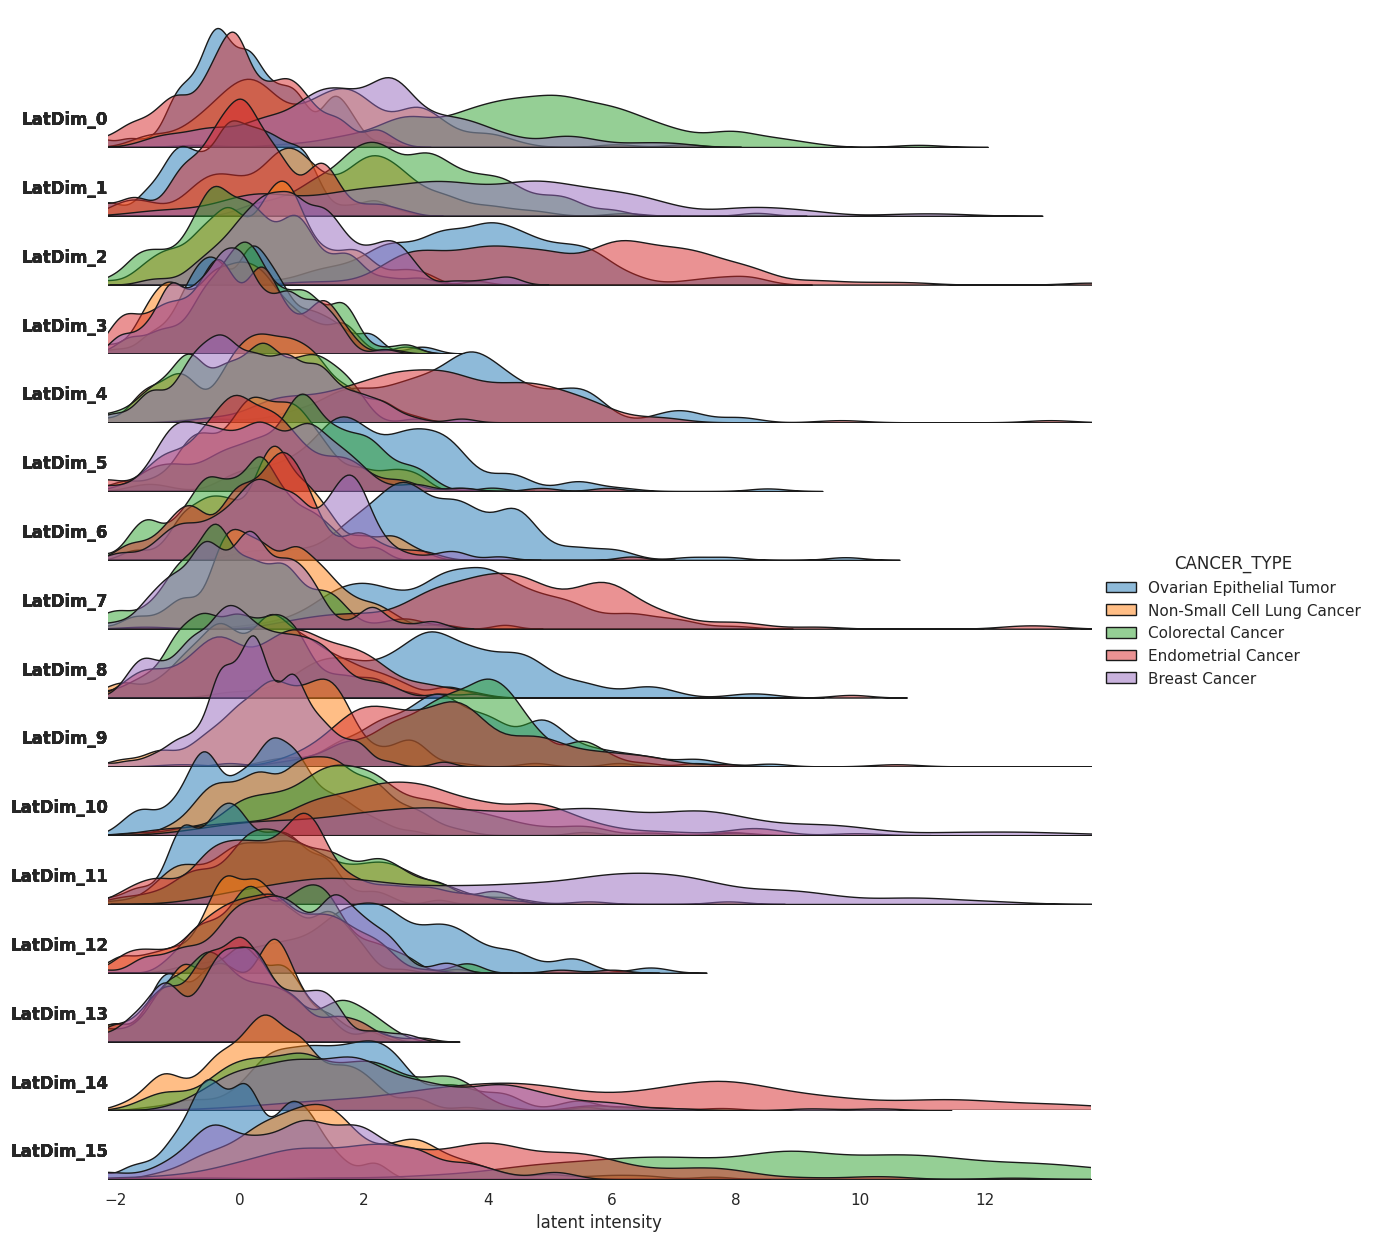

/home/alicia/dev/biomarker_autoencoder/autoencodix_package/src/autoencodix/utils/_result.py:348: UserWarning: Could not retrieve latent representations for epoch 99 and split 'train'. Returning empty DataFrame. This may be due to missing data in the Result object or incorrect keys.


  warnings.warn(
/home/alicia/dev/biomarker_autoencoder/autoencodix_package/src/autoencodix/utils/_result.py:348: UserWarning: Could not retrieve latent representations for epoch 99 and split 'valid'. Returning empty DataFrame. This may be due to missing data in the Result object or incorrect keys.


  warnings.warn(


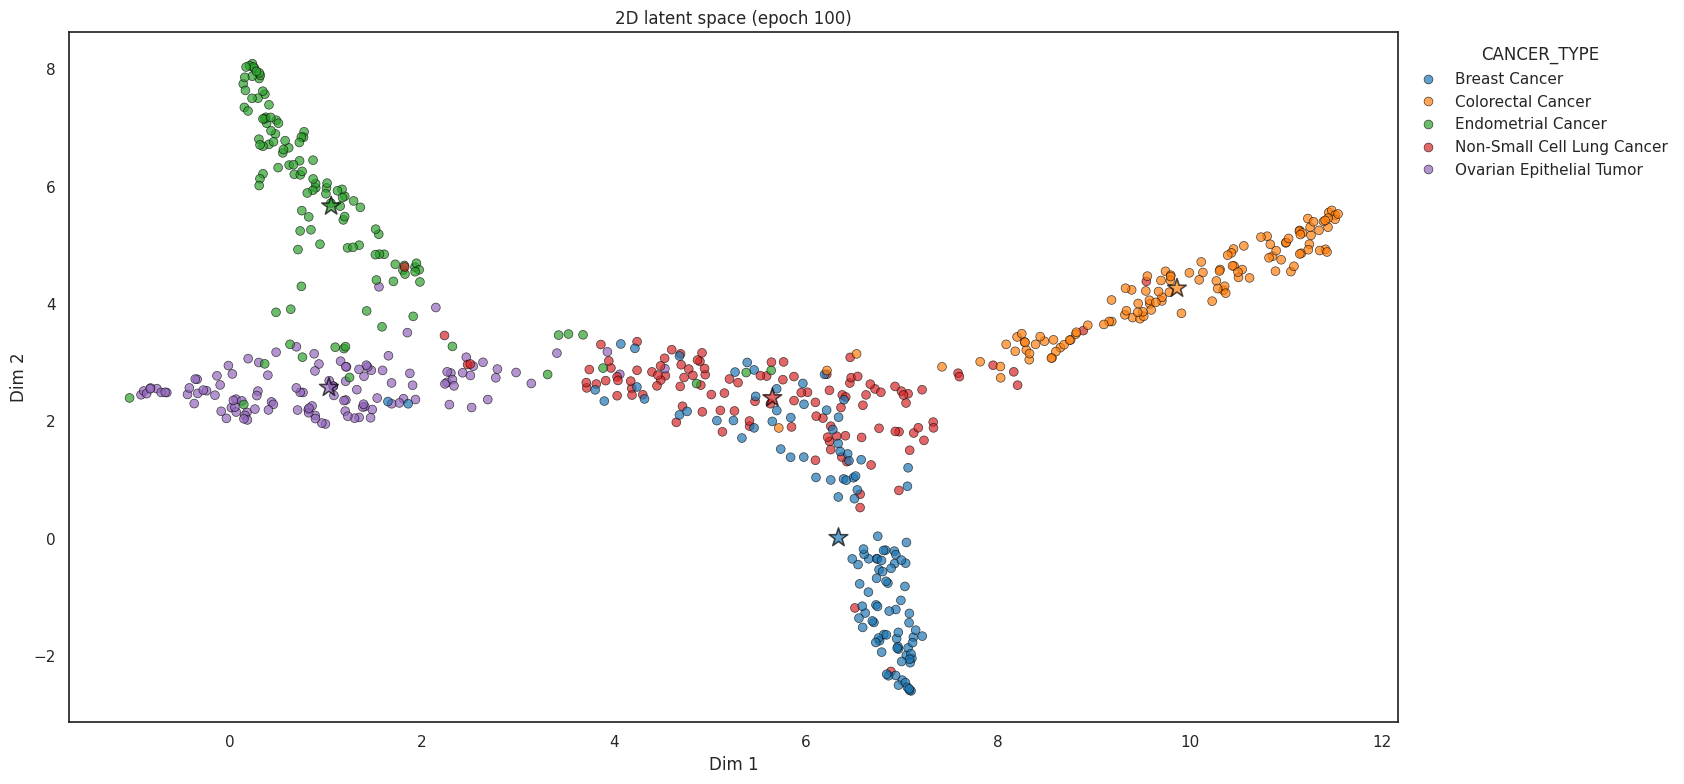

In [10]:
stackix_loaded.show_result(params=["CANCER_TYPE"])

#### Generate New Data
For a variational autoencoder, the generate or sample_latent_space step draws new latent vectors from the model’s learned latent distribution.

**Latent Sampling:** 
The model first aggregates the posterior over all encoded latent vectors in the chosen split and epoch by computing the mean (global_mu) and log-variance (global_logvar). It then samples new latent points from a diagonal Gaussian defined by these aggregate statistics, using the reparameterization trick to inject Gaussian noise.

**Number of Samples (n_samples):** 
Users can specify how many latent points to generate. The method expands the aggregated mean and log-variance to match the requested number of samples before sampling.

**Custom Latent Prior:** 
Optionally, a custom latent_prior can be provided (a tensor or NumPy array with shape (n_samples, latent_dim)), which will be used directly instead of the aggregated posterior. This is basically the `decode` step.


In [11]:
generated_reconstructions = stackix_loaded.generate(n_samples=5)
print(generated_reconstructions)

Reproducibility settings for device auto are not implemented or necessary i.e. for cpu.
tensor([[3.5112, 2.9113, 4.3990, 3.1104, 1.9875, 1.1828, 3.6146, 2.8797, 1.3758,
         3.1404, 3.4104, 2.3284, 3.4600, 0.6277, 2.7144, 3.3940, 3.1049, 2.0833,
         3.6760, 2.7922, 1.3083, 1.2193, 2.9025, 2.6948, 0.8958, 2.6837, 2.0716,
         2.6095, 1.6118, 0.5639, 1.6570, 2.5039],
        [4.9346, 1.7003, 4.1375, 5.0286, 2.5225, 0.9078, 4.6842, 4.1465, 0.7023,
         3.9739, 3.2848, 3.5913, 3.2528, 1.0938, 1.2224, 2.6108, 5.5426, 1.4944,
         2.8861, 5.2665, 2.2595, 1.1918, 4.0526, 4.5332, 0.7240, 3.1927, 1.7803,
         3.6502, 3.5343, 1.4817, 0.4913, 1.6481],
        [1.8989, 3.0677, 2.9250, 2.2008, 1.6610, 1.4799, 2.0613, 1.0171, 2.4279,
         1.5125, 2.0025, 0.6505, 4.8214, 2.1490, 3.6480, 3.4930, 1.2425, 2.2582,
         3.0299, 1.1288, 0.6420, 1.0729, 1.4150, 0.7498, 2.4043, 1.1391, 1.5017,
         1.3054, 2.8286, 1.7729, 2.8708, 2.5627],
        [4.0732, 2.5656, 3.7862, 